# Лабораторная работа 3. Нейронные сети в NLP.

Результатом лабораторной работы является отчет. Мы предпочитаем принимать отчеты в формате ноутбуков IPython (ipynb-файл). Постарайтесь сделать ваш отчет интересным рассказом, последовательно отвечающим на вопросы из заданий. Помимо ответов на вопросы, в отчете также должен быть код, однако чем меньше кода, тем лучше всем: нам — меньше проверять, вам — проще найти ошибку или дополнить эксперимент. При проверке оценивается четкость ответов на вопросы, аккуратность отчета и кода.

Мы уверены, что выполнение лабораторных работ занимает значительное время, поэтому не рекомендуем оставлять их на последний вечер перед сдачей.

## Рекуррентные языковые модели и трансформеры (16 баллов + бонусные 0-11 баллов)

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSj85jp-W-V-Bz8ZBjFJYIkV1TTxQxTMh4iqls_rRt8O-sraL08PA)

В этой части домашней работы мы создадим языковую модель на рекуррентных нейросетях (RNN) и заставим её придумывать имена.

__Языковая модель__, если вкратце, — это модель, которая умеет предсказывать вероятность некоторого текста. Ее можно использовать также для генерирации нового текста в соответствии с обученными вероятностями. Задание будет заключаться в том, чтобы научить модель генерировать новые имена, скормив ей для этого 8к существующих.

В данном случае в качестве входных данных мы будет работать со строками, которые можно рассматривать как последовательности _символов_: $\{x_0, x_1, x_2, ..., x_n\}$.

Наша основная задача — научиться предсказывать вероятность следующего символа:
$$ p(x_0, x_1, x_2, ..., x_n) = \prod_t p(x_t | x_0, ... x_{t - 1}) $$

In [227]:
import os
os.environ["OPENBLAS_NUM_THREADS"]="1"

In [228]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### Данные

Мы будем строить языковую модель по ~8k человеческих имён на латинице. Если когда-нибудь вам нужно будет дать имя своему ребёнку, у вас будет для этого генеративная нейросетевая модель.

Давайте их прочитаем:
* Считайте все строки из файла `names` в список
* В начало каждой строки допишите __пробел__
* В конце сроки не должно быть переноса (`\n`)

In [327]:
start_token = " "

lines = []
with open("data/names.txt", "r") as f:
    for line in f.readlines():
        lines.append(start_token + line[:-1])

lines = np.array(lines)

Разобьём имена на test и train, чтобы считать Perplexity

In [328]:
lines_train, lines_test = train_test_split(lines, test_size=0.33, random_state=42)
print(lines_train.shape, lines_test.shape)

(5322,) (2622,)


In [329]:
assert all(line[0] == start_token for line in lines)
assert all(line[-1] != '\n' for line in lines)

In [330]:
print ('n samples = ', len(lines))
for x in lines[::1000]:
    print (x)

n samples =  7944
 Abagael
 Claresta
 Glory
 Liliane
 Prissie
 Geeta
 Giovanne
 Piggy


Проверьте, что все корректно:

In [331]:
MAX_LENGTH = max(map(len, lines))
print("max length =", MAX_LENGTH)
assert MAX_LENGTH == 16 , "max length (for names) should be 16. remove assert if you work on different dataset"

max length = 16


## Словари

В начале нам будет необходимо построить "словарь" — упорядоченное множество уникальных символов, которые сеть может породить. Это нужно, чтобы уметь сопоставить каждому символу свой номер. Перед отправкой в сеть все символы будут кодироваться их номерами в словаре.

Также необходимо добавить в словарь пробельный символ, который будет использоваться в качестве специального токена.

In [332]:
tokens = set()

token_num = 0
for line in lines:
    for char in line:
        tokens.add(char)


tokens = sorted(list(tokens))

n_tokens = len(tokens)
print ('n_tokens = ', n_tokens)

assert 50 < n_tokens < 60

n_tokens =  55


А теперь построим обратный словарь: для каждой буквы посчитаем её номер в списке токенов.

In [333]:
token_to_id = {token: i for i, token in enumerate(tokens)}

И проверим, все ли корректно:

In [334]:
assert len(tokens) == len(token_to_id), "число токенов должно совпадать"

for i in range(n_tokens):
    assert token_to_id[tokens[i]] == i, "словарь должен указывать на индекс буквы в tokens"

print("Кажется заработало...")

Кажется заработало...


Имея построенное соответствие, можно преобразовать батч входных данных в матрицу int32 номеров токенов. Так как в батче все строки должны быть одной длины, слишком короткие строки в батче нужно будет дополнить пробелами (паддинг).

In [335]:
def to_matrix(lines, max_len=None, pad=token_to_id[' '], dtype='int32'):
    """Casts a list of names into rnn-digestable matrix"""
    max_len = max_len or max(map(len, lines))
    lines_ix = np.zeros([len(lines), max_len], dtype) + pad

    for i in range(len(lines)):
        line_ix = list(map(token_to_id.get, lines[i]))
        lines_ix[i, :len(line_ix)] = line_ix

    return lines_ix

In [238]:
print('\n'.join(lines[::2000]))
print(to_matrix(lines[::2000]))

 Abagael
 Glory
 Prissie
 Giovanne
[[ 0  3 30 29 35 29 33 40  0]
 [ 0  9 40 43 46 53  0  0  0]
 [ 0 18 46 37 47 47 37 33  0]
 [ 0  9 37 43 50 29 42 42 33]]


## Один шаг RNN

Рекуррентная нейронная сеть (RNN) — это такая сеть с <s>блокнотом</s> состоянием $h$, в который она умеет писать то, что видела.

Сеть начинает с пустого $h_0 = \vec 0$, после чего текст обрабатывается по одному символу:
* $x_t$ — очередной символ, $h_t$ — предыдущее состояние
* $h_{t+1} = \text{get\_h\_next}(h_t, x_t)$ — новое состояние
* $p(x_{t+1} | h_{t+1}) = \text{get\_probs}(h_{t+1})$ — вероятность следующего символа



<img src="https://i.imgur.com/8l4qFF0.png" width=480>

Поскольку $x_t$ — это индекс символа в словаре (натуральное число), то ему можно сопоставить некоторый обучаемый вектор (*embedding*).

**Задание 1 (2 балла)**. Реализуйте вычисление нового состояния *get_h_next* и вероятности следующего символа *get_probs*, после чего напишите код для одного шага рекуррентной сети *rnn_one_step*, как на схеме выше.

In [336]:
import torch
import torch.nn as nn
import math
from torchmetrics.text import Perplexity


emb_size, rnn_size = 16, 64

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


Создадим слой, который сопоставляет каждому из n_tokens входов свой обучаемый вектор:

In [240]:
embed_x = nn.Embedding(n_tokens, emb_size)

Теперь инициализируем слой, вычисляющий следующее состояния $[emb(x_t), h_t] \to h_{t+1}$.

In [241]:
get_h_next = nn.Sequential(
    nn.Linear(rnn_size + emb_size, rnn_size),
    nn.Tanh()
)

И, наконец, слой предсказывающий вероятности $h_{t+1} \to P(x_{t+1}|h_{t+1})$.

In [242]:
get_logits = nn.Sequential(
    nn.Linear(rnn_size, 128),
    nn.Tanh(),
    nn.Linear(128, n_tokens)
)


Для реализации одного шага RNN реализуйте следующую последовательность действий:
1. замените номер символа на его вектор (embedding) (*hint*: возможно, вам потребуется torch.reshape);
2. сконкатенируйте вектор входа и предыдущее состояние;
3. вычислите следующее состояние сети;
4. предскажите вероятности для языковой модели P(x_next | h_next).

In [243]:
def rnn_one_step(x_t, h_t):    
    emb = embed_x(x_t.reshape(-1))
    concated = torch.concatenate([h_t, emb], dim=1)
    h_next = get_h_next(concated)
    output_logits = get_logits(h_next)
    
    return h_next, output_logits

Проверим, что все работает:

In [244]:
batch_size = 32
input_sequence = torch.randint(0, 10, (batch_size, MAX_LENGTH))

# начальное состояние из нулей
h0 = torch.zeros([batch_size, rnn_size])

In [245]:
h1, p_y1 = rnn_one_step(input_sequence[:, 0], h0)
print(input_sequence[:, 0].shape, h0.shape)

assert h1.shape == (batch_size, rnn_size)
# assert p_y1.detach().numpy().shape == (batch_size, n_tokens) and np.allclose(p_y1.detach().numpy().sum(-1), 1)

torch.Size([32]) torch.Size([32, 64])


## Много шагов RNN

После того как был реализован один шаг нейросети, самое время сделать этих шагов побольше. Самый простой способ это сделать — написать цикл для фиксированного числа шагов (`MAX_LENGTH`).

**Задание 2 (2 балла)**. Реализуйте много шагов рекуррентной сети, на каждом шаге вычисляя следующее состояние RNN, исходя из предыдущего, при этом не забывая про *get_h_next* и *get_probs*.

In [246]:
h_prev = h0
predicted_probs = []

for t in range(MAX_LENGTH):
    x_t = input_sequence[:, t]
    h_next, logits_next = rnn_one_step(x_t, h_prev)
    
    predicted_probs.append(logits_next)
    h_prev = h_next
    
predicted_probs = torch.stack(predicted_probs, dim=1)

In [247]:
assert list(predicted_probs.shape) == [batch_size, MAX_LENGTH, n_tokens]
assert list(h_prev.shape) == list(h0.shape)

## Обучение RNN

Как и любую вероятностную модель, RNN можно обучить методом максимизации log-правдоподобия по всей выборке $D$:

$$ \theta = \underset \theta {argmax} \log P(D) $$

где
$$ \log P(D) = \underset {\vec x \in D} \sum \log P(\vec x) = \underset {\vec x \in D} \sum \underset {x_t \in \vec x} \sum \log P(x_t | x_0, ..., x_{t+1})$$

C тем же успехом мы можем __минимизировать__ кроссэнтропию — то же самое, но с минусом.

In [248]:
predictions_matrix = predicted_probs[:, :-1]
answers_matrix = torch.nn.functional.one_hot(input_sequence[:, 1:], n_tokens) 

print('predictions_matrix:', predictions_matrix.shape)
print('answers_matrix:', predictions_matrix.shape)

predictions_matrix: torch.Size([32, 15, 55])
answers_matrix: torch.Size([32, 15, 55])


**Задание 3 (2 балла)**. Реализуйте вычисление функции потерь (кроссэнтропия) и шаг градиентного спуска.

In [249]:
loss = nn.functional.cross_entropy

optimize = torch.optim.Adam([
    {"params": embed_x.parameters()},
    {"params": get_h_next.parameters()},
    {"params": get_logits.parameters()}
])

### Цикл обучения

**Задание 4 (2 балл)**. Напишите цикл обучения:
1. выбираем `batch_size` случайных строчек
2. преобразуем их в матрицу индексов
3. вычисляем функцию потерь и делаем шаг обучения
4. записываем функцию потерь в `history`

Для удобства отладки рекомендуем печатать или рисовать промежуточные результаты раз в несколько итераций.

In [250]:
batch_size = 32
history = []

In [251]:
for i in range(1000):
    batch = np.random.choice(lines, size=batch_size)
    batch_matrix = torch.tensor(to_matrix(batch, max_len=MAX_LENGTH), dtype=torch.long)
    
    h_prev = torch.zeros([batch_size, rnn_size])
    total_loss = 0
    for t in range(MAX_LENGTH - 1):
        x_t = batch_matrix[:, t]
        h_next, logits_next = rnn_one_step(x_t, h_prev)
        
        target = batch_matrix[:, t + 1]
        loss_t = loss(logits_next, target)
        total_loss += loss_t
        
        h_prev = h_next
    
    total_loss.backward()
    optimize.step()
    optimize.zero_grad()
    
    
    history.append(total_loss.item() / (MAX_LENGTH - 1))

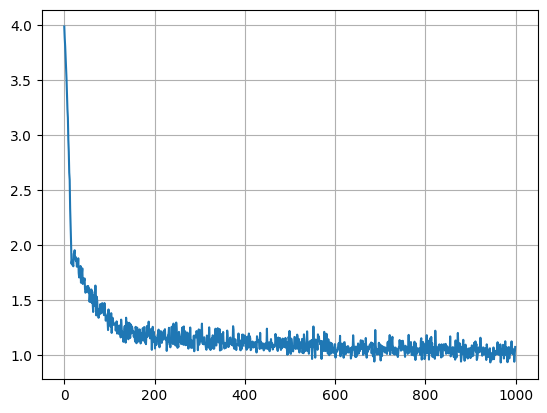

In [252]:
plt.plot(history)
plt.grid()

## Применение RNN

Только что у нас обучилась модель, которая предсказывает вероятности следующего символа.
Теперь давайте применим её к строке из одного пробела. Получим вероятности первой буквы имени. После чего:
* $x_t \sim P(x_t | h_t)$ — выберем букву пропорционально вероятностям.
* $h_{t+1} = \text{get\_h\_next}(h_t, x_t)$ — присоединим букву к имени и прогоним через RNN

Для начала инициализируем необходимые переменные:

In [253]:
x_t = torch.tensor([[token_to_id[" "]]])
print(" ")
h_t = torch.tensor([[0 for _ in range(rnn_size)]])
next_h, logits = rnn_one_step(x_t, h_t)

for _ in range(MAX_LENGTH - 1):
    probs = torch.softmax(logits, dim=1).reshape(-1)    
    x_t = np.random.choice(n_tokens, p=probs.detach().numpy())
    print(tokens[x_t], end='')
    x_t = torch.tensor([[x_t]])
    next_h, logits = rnn_one_step(x_t, next_h)

 
Claudy         

**Задание 5 (1 балл).** Напишите функцию, генерируюущю новые имена:

In [254]:
def generate_sample(seed_phrase=' ', max_length=MAX_LENGTH, temperature=1.0):
    '''
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs,
                        smaller temperature converges to the single most likely output
    '''
    
    word = [c for c in seed_phrase]
    h_prev = torch.zeros(size=(1, rnn_size))
    
    for i in range(len(word) - 1):
        current_input_token = torch.tensor(token_to_id[word[i]])
        h_next, _ = rnn_one_step(current_input_token, h_prev)
        h_prev = h_next
    
    for _ in range(max_length - len(seed_phrase)):
        current_input_token = torch.tensor(token_to_id[word[-1]])
        h_next, logits = rnn_one_step(current_input_token, h_prev)
        temperatured_probs = torch.softmax(logits / temperature, dim=1)
        next_token = tokens[np.random.choice(n_tokens, p=temperatured_probs.detach().numpy().reshape(-1))]
        
        word.append(next_token)
    
        h_prev = h_next
    
    
    return "".join(word)


Посмотрим, что же придумала наша модель:

In [255]:
for _ in range(10):
    print(generate_sample())

 Mosinau        
 Ke             
 Juury          
 Gargela        
 Nafsovl        
 Vewide         
 Baporty        
 Fannanna       
 Sariesp        
 Sabelta        


In [256]:
for _ in range(50):
    print(generate_sample(' Trump', temperature=1.2))

 Trump          
 Trumpe         
 Trump          
 Trumpe         
 Trumpe r       
 Trumpnh        
 Trumpay        
 Trumpg         
 Trumpi         
 Trumpy         
 Trumpa         
 Trump          
 Trumpa         
 Trumpe         
 Trumpes        
 Trumpe         
 Trump          
 Trumpe         
 Trumpe         
 Trumpealina    
 Trumpa         
 Trumpy         
 Trump          
 Trumpsen       
 Trumpa         
 Trump          
 Trumpa         
 Trumpe         
 Trumpou        
 Trumpia        
 Trumpe Me      
 Trumpoli       
 Trumpe         
 Trumpi         
 Trumpy         
 Trumpe         
 Trumpa         
 Trump          
 Trumpe         
 Trumpton       
 Trumpl         
 Trump          
 Trumpy         
 Trump          
 Trumpe         
 Trumpeve       
 Trumpa         
 Trumpree       
 Trumpe         
 Trumpet        


### Написание своей ячейки RNN - 1 балл + бонусные 0-8 баллов

Вот у вас и готова своя генеративная модель для придумывания имён. Теперь усложним её, используя чуть менее игрушечную архитектуру. В качестве рекапа того, что мы проходили на паре, прочитайте главу учебника https://education.yandex.ru/handbook/ml/article/nejroseti-dlya-raboty-s-posledovatelnostyami#rekurrentnye-nejronnye-seti.

Выберите один из пунктов ниже и замените вашу RNN ячейку на собственную реализацию:

1. Vanilla RNN - 1 обычный балл  
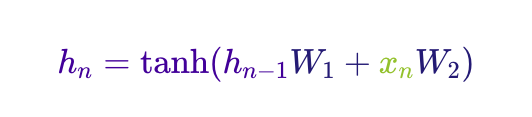

2. LSTM - 2 бонусных балла
3. GRU - 2 бонусных балла
4. Linear Recurrent Unit - 4 бонусных балла

Для реализации решения пунктов 1-3 возможно, потребуются: статья с пары, теория в учебнике, исходникам торча. 4 пункт сильно для любителей - обратитесь к статье [Resurrecting Recurrent Neural Networks for Long Sequences](https://paperswithcode.com/paper/resurrecting-recurrent-neural-networks-for). За бездумный копипаст буду карать, так что готовьтесь отвечать на вопросы, зачем та или иная строчка. За выполнение нескольких пунктов бонусные баллы суммируются.

Используйте новую ячейку, обучите вашу модель, и сравните её качество "на глаз" и по метрике с предыдущей.
В качестве метрики возьмите перплексию: https://habr.com/ru/companies/wunderfund/articles/580230/

In [257]:
class RnnBase(nn.Module):
    def __init__(self, n_tokens):
        super().__init__()
    
        self.n_tokens = n_tokens
    
    def _rnn_one_step(self, x_t):
        pass
    
    def clear_states(self):
        pass
    
    
    def forward(self, batch_matrix): # [bs, seq_len]
        self.clear_states()
        
        x_t = batch_matrix[:, 0] # [bs, 1]
        _, logits_next = self._rnn_one_step(x_t)
        logits = logits_next.unsqueeze(1)
        
        for t in range(1, batch_matrix.shape[1]):
            x_t = batch_matrix[:, t] # [bs, 1]
            _, logits_next = self._rnn_one_step(x_t)
            logits = torch.concatenate([logits, logits_next.unsqueeze(1)], dim=1)
        
        return logits
    
    
    def _get_last_token_idx(self, logits, temperature): # [seq_len, n_tokens]
        probs = torch.softmax(logits / temperature, dim=1)
        next_token_probs = probs[-1, :].reshape(-1)
        return np.random.choice(self.n_tokens, size=1, p=next_token_probs.detach().numpy()) # [1]

    def genereate(self, seq, temperature): # [seq_len]
        result = [el.item() for el in seq.reshape(-1)]
        
        seq = seq.reshape((1, seq.shape[0]))
        logits = self.forward(seq)
        token = self._get_last_token_idx(logits.squeeze(0), temperature)
        next_token = token[0]
        
        while next_token != 0 and seq.shape[1] < self.max_seq_len:
            result.append(next_token)
            
            next_token = torch.tensor([[next_token]])
            seq = torch.concatenate([seq, next_token], dim=1)
            logits = self.forward(seq)
            token: np.ndarray = self._get_last_token_idx(logits.squeeze(0), temperature)
            next_token = token[0]
        
        return torch.tensor(result)

In [258]:
class VanillaRNN(RnnBase):
    def __init__(self, n_tokens, emb_size, rnn_size, max_seq_len, hidden_size):
        super().__init__(n_tokens)
        
        self.emb_size = emb_size
        self.rnn_size = rnn_size
        self.max_seq_len = max_seq_len
        
        self.embedding = nn.Embedding(n_tokens, emb_size)
        
        self.W1 = nn.Linear(rnn_size, rnn_size)
        self.W2 = nn.Linear(emb_size, rnn_size)
        
        self.classifier = nn.Sequential(
            nn.Linear(rnn_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, n_tokens)
        )
        
        self.h_prev = None
    
    
    def _rnn_one_step(self, x_t):
        if self.h_prev is None:
            self.h_prev = torch.zeros(size=(x_t.shape[0], self.rnn_size), device=x_t.device)
        
        emb = self.embedding(x_t.reshape(-1))
        h_next = torch.tanh(self.W1(self.h_prev) + self.W2(emb))
        output_logits = self.classifier(h_next)
        self.h_prev = h_next
        
        return h_next, output_logits

    
    def clear_states(self):
        self.h_prev = None


In [259]:
class LSTM(RnnBase):
    def __init__(self, n_tokens, emb_size, rnn_size, max_seq_len, hidden_size):
        super().__init__(n_tokens)
        
        self.emb_size = emb_size
        self.rnn_size = rnn_size
        self.max_seq_len = max_seq_len
        
        self.embedding = nn.Embedding(self.n_tokens, self.emb_size)
        
        self.forget_gate = nn.Sequential(
            nn.Linear(self.rnn_size + self.emb_size, self.rnn_size),
            nn.Sigmoid()
        )
        
        self.information_gate = nn.Sequential(
            nn.Linear(self.rnn_size + self.emb_size, self.rnn_size), 
            nn.Sigmoid()
        )
        
        self.candidate_values = nn.Sequential(
            nn.Linear(self.rnn_size + self.emb_size, self.rnn_size), 
            nn.Tanh()
        )
        
        self.output = nn.Sequential(
            nn.Linear(self.rnn_size + self.emb_size, self.rnn_size),
            nn.Sigmoid()
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(rnn_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, n_tokens)
        )
        
        self.h_prev = None
        self.C_prev = None


    def _rnn_one_step(self, x_t): # [bs, 1]
        if self.h_prev is None:
            self.h_prev = torch.zeros(size=(x_t.shape[0], self.rnn_size), device=x_t.device)
        
        if self.C_prev is None:
            self.C_prev = torch.zeros(size=(x_t.shape[0], self.rnn_size), device=x_t.device)
        
        emb = self.embedding(x_t.reshape(-1)) # [bs, emb_size]
        concat = torch.concatenate([self.h_prev, emb], dim=1)
        
        forget = self.forget_gate(concat)
        information = self.information_gate(concat)
        new_candidate_values = self.candidate_values(concat)
        out = self.output(concat)
        
        C_next = forget * self.C_prev + information * new_candidate_values
        h_next = out * C_next
        self.h_prev = h_next
        self.C_prev = C_next
        
        output_logits = self.classifier(h_next)
        
        return h_next, output_logits

        
    def clear_states(self):
        self.h_prev = None
        self.C_prev = None

In [260]:
from torch.utils.tensorboard import SummaryWriter


def fit(
    model, 
    n_epochs, 
    loss, 
    opt, 
    train_lines, 
    history=None, 
    scheduler=None, 
    writer: SummaryWriter=None, 
    pad=token_to_id[" "]):
    
    model.to(device)
    model.train()
    for epoch in range(n_epochs):
        batch = np.random.choice(train_lines, size=batch_size)
        batch_matrix = torch.tensor(to_matrix(batch, max_len=model.max_seq_len, pad=pad), dtype=torch.long).to(device)
        
        logits = model(batch_matrix).permute(0, 2, 1)[:, :, :-1] # [bs, seq_len - 1, n_tokens]
        target = batch_matrix[:, 1:]
        batch_loss = loss(logits, target)
        
        batch_loss.backward()
        opt.step()
        
        if scheduler:
            scheduler.step()
        if writer:
            writer.add_scalar("Loss/train", batch_loss.item(), epoch)
            
        opt.zero_grad()
        
        if history is not None:
            history.append(batch_loss.item())


def perplexity(model, data_lines):
    model.eval()
    model.to(device)
    perp = Perplexity(ignore_index=token_to_id[" "]).to(device)
    with torch.no_grad():
        pred = model(torch.tensor(to_matrix(data_lines, model.max_seq_len), dtype=torch.long, device=device))[:, :-1]
        target = torch.tensor(to_matrix(data_lines, model.max_seq_len), dtype=torch.long, device=device)[:, 1:]

        return perp(pred, target)


def run_one_experiment(experiment: dict):
    model = experiment["model_fn"](**experiment["model_params"])
    optimizer = experiment["optimizer_fn"](model.parameters())

    scheduler = None
    if experiment.get("scheduler_fn"):
        scheduler = experiment["scheduler_fn"](optimizer)

    fit(
        model=model,
        opt=optimizer,
        scheduler=scheduler,
        **{k: v for k, v in experiment.items()
           if k not in ["model_fn", "optimizer_fn", "scheduler_fn", "model_params"]}
    )

def run_experiments(experiments: list[dict]):
    
    for experiment in experiments:
        run_one_experiment(experiment)

    

In [261]:
vanilla_rnn = VanillaRNN(n_tokens=n_tokens, emb_size=emb_size, rnn_size=rnn_size, max_seq_len=MAX_LENGTH, hidden_size=64)
opt = torch.optim.AdamW(vanilla_rnn.parameters())
history = []
fit(
    model=vanilla_rnn, 
    n_epochs=1000, 
    loss=nn.functional.cross_entropy, 
    opt=opt, 
    train_lines=lines, 
    history=history)

In [262]:
perplexity(vanilla_rnn, lines)

tensor(11.3209, device='cuda:0')

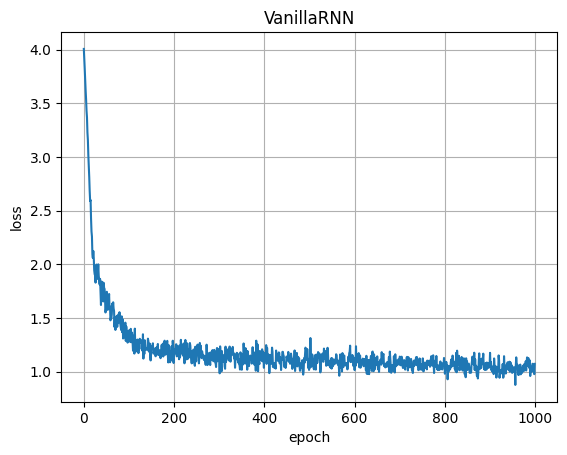

In [263]:
plt.title("VanillaRNN")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.plot(history)
plt.grid(True)

In [264]:
lstm_rnn = LSTM(n_tokens=n_tokens, emb_size=128, rnn_size=128, max_seq_len=MAX_LENGTH, hidden_size=256)
opt = torch.optim.AdamW(lstm_rnn.parameters())
history = []
fit(lstm_rnn, 1000, nn.functional.cross_entropy, opt, lines_train, history)

In [265]:
perplexity(lstm_rnn, lines_test)

tensor(9.5501, device='cuda:0')

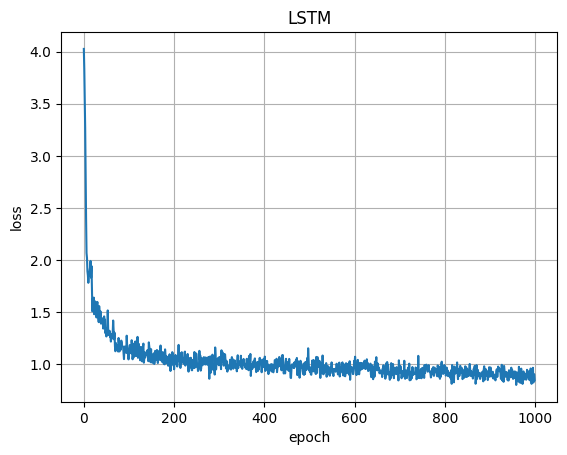

In [266]:
plt.title("LSTM")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.plot(history)
plt.grid(True)

Как можно видеть из графика выше LSTM выдаёт результаты по лоссу и по перплексии лучше, чем VanillaRNN

### Обучение своего transformer-а - 3 балла

А теперь предстоит заиспользовать то, что используется во всех современных генеративках - decoder блок трансформера (конечно что с self attention). Не зря ведь он был разобран на семинаре

Замените вашу RNN ячейку на собственную реализацию transformer-а. А именно, сделайте модель Decoder only.

Воспользуйтесь кодом с семинара и сделайте так, что б он обучился и имена генерировались

Используйте новую ячейку, обучите вашу модель, и сравните её качество "на глаз" и по метрике с предыдущей.
В качестве метрики возьмите перплексию: https://habr.com/ru/companies/wunderfund/articles/580230/

Напишем multi-head attention.  (Основной код из семинара)  
Также добавим mask-attention, чтобы Transformer смотрел только в прошлое

In [267]:
class MultiHeadAttention(nn.Module):
    """
    Class to calculate Multi-head attention (or Masked Multi-head attention for decoder) operation
    """
    def __init__(self, in_size, head_size, num_heads, out_size, query_in_size=None):
        """
        Args:
            in_size: embedding size of input
            head_size: hidden size of Q, K, V matrices
            num_heads: number of heads
            out_size: output embedding size
            query_in_size: embedding size of input for query (if not provided - same as in_size)
        """
        super().__init__()

        # Запишем все переданые гиперпараметры слоя
        self.in_size = in_size
        self.head_size = head_size
        self.num_heads = num_heads
        self.out_size = out_size
        self.query_in_size = self.in_size if query_in_size is None else query_in_size
       
        # Линейные преобразования для Q, K, V матриц (сразу хотим получить все Q, K, V матрицы)
        self.query_matrix = nn.Linear(self.query_in_size, num_heads * head_size)
        self.key_matrix = nn.Linear(in_size, num_heads * head_size)
        self.value_matrix = nn.Linear(in_size, num_heads * head_size)
        
        # Линейное преобразование для получения выхода после конкатенации голов
        self.out = nn.Linear(num_heads * head_size, out_size)

    def forward(self, query, key, value, mask=None):
        """
        Args:
           query : tensor for query
           key : tensor for key
           value : tensor for value
           mask: mask for decoder
        
        Returns:
           output vector from multihead attention
        """
        # Тензоры приходят размера batch_size x seq_len x in_size
        batch_size = key.size(0)
        seq_len = key.size(1)
        
        # Число токенов в query будет другим для decoder-а
        query_seq_len = query.size(1)
       
        # Применяем линейные преобразования на входе
        q = self.query_matrix(query)
        k = self.key_matrix(key)
        v = self.value_matrix(value)
        
       
        # Пилим на разные головы
        # ЭТО ГЕНИАЛЬНО, Я В АХЕРЕ, КАК ЭТО ПРОСТО РАБОТАЕТ
        q = q.view(batch_size, query_seq_len, self.num_heads, self.head_size)
        # q [bs, query_seq_len, num_heads, head_size]
        q = q.transpose(1, 2)
        # q [bs, num_heads, query_seq_len, head_size]
        
        k = k.view(batch_size, seq_len, self.num_heads, self.head_size).transpose(1, 2)
        v = v.view(batch_size, seq_len, self.num_heads, self.head_size).transpose(1, 2)
        # v [bs, num_heads, seq_len, head_size]

        # Считаем релевантность
        relevance = q @ k.transpose(2, 3) # relevance [bs, num_heads, query_seq_len, seq_len]
        
        
        # Задача маски сделать так, чтобы для каждого x_i вектора был виден только attention предыдущих векторов, то есть Decoder может смотреть только в прошлое
        # Без Mask Decoder смотрел бы на Attention будущего и это было бы DataLeak, то есть моделька могла бы просто скопировать нужные токены и всё, и не научилась бы предсказывать
        # Если есть маска (для декодера), то заполняем значения по маске как минус бесконечность (чтобы exp(r) = 0 в softmax)
        if mask is not None:
            mask = mask.expand(batch_size, self.num_heads, query_seq_len, query_seq_len)
            relevance = relevance.masked_fill(~mask, float("-inf"))

        # Получаем вероятности
        relevance = torch.softmax(relevance / math.sqrt(self.head_size), dim=3)

 
        # Считаем выходы из каждой головы
        head_i = relevance @ v # head_i [bs, num_head, query_seq_len, head_size]
        
        # Конкатенируем выходы
        concat = head_i.transpose(1, 2).reshape(batch_size, query_seq_len, self.num_heads * self.head_size)
        
        # Финальное линейное преобразование
        return self.out(concat)

In [268]:
def make_decoder_mask(decoder_embed):
    """
    Make mask for decoder Masked Multi-head Attention based on input sequence
    Args:
        decoder_embed: decoder sequence after embed
    Returns:
        mask: mask for Masked Multi-head Attention
    """
    batch_size, decoder_seq_len, _ = decoder_embed.shape
    mask = torch.tril(torch.ones((decoder_seq_len, decoder_seq_len))).expand(
        batch_size, 1, decoder_seq_len, decoder_seq_len
    ).bool().to(decoder_embed.device)
    
    return mask 

Напишем блок PositionalEncoding

In [269]:
class PositionalEncoding(nn.Module):
    """
    Class to calculate Positional Encodings, suggested in `Attention is all you need [Vaswaniet al., 2017]`
    """
    def __init__(self, max_seq_len, emb_size):
        """
        Args:
            max_seq_len: max length of input sequence
            emb_size: demension of embedding
        """
        super().__init__()
        
        # Запишем все переданые гиперпараметры слоя
        self.max_seq_len = max_seq_len
        self.emb_size = emb_size
        
        # Посчитаем позиционные эмбеддинги в тензорном виде
        pos = torch.arange(max_seq_len)[:, None]
        inds = torch.arange(emb_size)[None, ::2]
        
        pe = torch.zeros(max_seq_len, self.emb_size)
        pe[:, ::2] = torch.sin(pos / (10000 ** ((2 * inds) / self.emb_size)))
        pe[:, 1::2] = torch.cos(pos / (10000 ** ((2 * inds) / self.emb_size)))
        pe = pe.unsqueeze(0)
        
        # Добавляем полученный тензор как параметр, который будет сохранятся вместе с моделью, но не будет обучаться
        self.register_buffer('pe', pe)


    def forward(self, decoder_emb):
        """
        Args:
            decoder_emb: decoder sequence after embed
        Returns:
            output: input with positional encodings
        """
        # Тензоры приходят размера batch_size x seq_len x emb_size
        seq_len = decoder_emb.size(1)
        
        # Прибавляем позиционные эмбеддинги
        return decoder_emb + self.pe[:, :seq_len]

Напишем блок декодера.

In [270]:
class TransformerDecoderOnlyBlock(nn.Module):
    """
    Class with one full block within transformer's decoder
    """
    def __init__(self, in_size, head_size, num_heads, out_size, ff_hidden_size, dropout_p=0.2):
        """
        Args:
           in_size: input embedding size
           head_size: size of each attention head
           num_heads: number of attention heads
           out_size: output embedding size
           ff_hidden_size: hidden size for feed forward net
           dropout_p: probability for dropout
           encoder_out_size: embedding size of outputs from encoder (if not provided - same as in_size)
        """
        super().__init__()
        
        # Запишем все переданые гиперпараметры слоя
        self.in_size = in_size
        self.head_size = head_size
        self.num_heads = num_heads
        self.out_size = out_size
        self.ff_hidden_size = ff_hidden_size
        self.dropout_p = dropout_p
        
        
        self.masked_attention = MultiHeadAttention(
            in_size=self.in_size,
            head_size=self.head_size,
            num_heads=self.num_heads,
            out_size=self.out_size,
        )
        # Если выход и вход attention-а имеют разный размер, то используем линейный слой на residual connection-е
        self.adapt_residual = nn.Linear(self.in_size, self.out_size)
        self.norm_attention = nn.LayerNorm(self.out_size)
        
        self.dropout = nn.Dropout(self.dropout_p)
        self.ff = nn.Sequential(
            nn.Linear(self.out_size, self.ff_hidden_size),
            nn.ReLU(),
            nn.Linear(self.ff_hidden_size, self.out_size)
        )
        self.norm_ff = nn.LayerNorm(self.out_size)
        
    
    def forward(self, decoder_emb):
        """
        Args:
           decoder_emb: decoder sequence after embed
           encoder_output: output from encoder
        """
        # Получаем на вход тензор batch_size x seq_len x in_size
        mask = make_decoder_mask(decoder_emb)  # batch_size x 1 x seq_len x seq_len
        
        attention = self.masked_attention(decoder_emb, decoder_emb, decoder_emb, mask)
        residual_out = attention + self.adapt_residual(decoder_emb)
        norm_attention = self.norm_attention(residual_out)
        after_attention_dropout = self.dropout(norm_attention)
        
        ff_residual = self.ff(after_attention_dropout) + after_attention_dropout
        block_out = self.norm_ff(ff_residual)

        # Обратим внимание, что на выходе у нас находится тензор размености [bs, seq_len, att_out]
        # То есть на выходе после линейного слоя у нас будут логиты для каждого символа в последовательности в одной строке - КРУТО! 
        
        return block_out

In [271]:
class TransformerDecoderOnly(nn.Module):
    """
    Class for decoder within transformer.
    """
    def __init__(self, max_seq_len, vocab_size, emb_size, num_layers, att_out_size, att_head_size, num_heads, ff_hidden_size, dropout_p):
        """  
        Args:
            max_seq_len : maximum length of input sequence
            vocab_size: size of the vocabulary
            emb_size: embeddings size
            num_layers: number of encoder layers
            att_out_size: output size for attention and each encoder block
            att_head_size: size of each attention head
            num_heads: number of heads in multihead attention
            ff_hidden_size: hidden size for feed forward net
            dropout_p: probability for dropout
            encoder_out_size: embedding size of outputs from encoder (if not provided - same as in_size)
        """
        super().__init__()
                
        # Запишем все переданые гиперпараметры слоя
        self.max_seq_len = max_seq_len
        self.vocab_size = vocab_size
        self.emb_size = emb_size
        self.num_layers = num_layers
        self.att_out_size = att_out_size
        self.att_head_size = att_head_size
        self.num_heads = num_heads
        self.ff_hidden_size = ff_hidden_size
        self.dropout_p = dropout_p
        
        self.embedding_layer = nn.Embedding(self.vocab_size, self.emb_size)
        self.positional_encoder = PositionalEncoding(self.max_seq_len, self.emb_size)
        self.dropout = nn.Dropout(self.dropout_p)

        self.decoder_blocks = nn.ModuleDict({
            f"decoder_block_{i}": TransformerDecoderOnlyBlock(
                in_size=self.emb_size if i == 0 else self.att_out_size,
                head_size=self.att_head_size,
                num_heads=self.num_heads,
                out_size=self.att_out_size,
                ff_hidden_size=self.ff_hidden_size,
                dropout_p=self.dropout_p,
            ) for i in range(self.num_layers)
        })
        
        self.fc = nn.Linear(self.att_out_size, self.vocab_size)


    def forward(self, decoder_input):
        """
        Args:
            decoder_input:
            encoder_output:
        Returns:
            out: output vector
        """
        # Получаем на вход batch_size x seq_len
        decoder_input = decoder_input.type(torch.long)
        decoder_emb = self.embedding_layer(decoder_input)  # batch_size x seq_len x emb_size
        decoder_emb_pos = self.positional_encoder(decoder_emb)

        out = self.dropout(decoder_emb_pos)
        for block in self.decoder_blocks.values():
            out = block(out)
        
        logits = self.fc(out)
        
        return logits

    def _get_last_token_idx(self, logits, temperature): # [seq_len, n_tokens]
        probs = torch.softmax(logits / temperature, dim=1)
        next_token_probs = probs[-1, :].reshape(-1)
        return np.random.choice(n_tokens, size=1, p=next_token_probs.detach().numpy()) # [1]

    def genereate(self, seq, temperature): # [seq_len]
        result = [el.item() for el in seq.reshape(-1)]
        
        seq = seq.reshape((1, seq.shape[0]))
        logits = self.forward(seq)
        token = self._get_last_token_idx(logits.squeeze(0), temperature)
        next_token = token[0]
        
        while next_token != 0 and seq.shape[1] < self.max_seq_len:
            result.append(next_token)
            
            next_token = torch.tensor([[next_token]])
            seq = torch.concatenate([seq, next_token], dim=1)
            logits = self.forward(seq)
            token: np.ndarray = self._get_last_token_idx(logits.squeeze(0), temperature)
            next_token = token[0]
        
        return torch.tensor(result)
    

In [272]:
decoder_model = TransformerDecoderOnly(
    max_seq_len=MAX_LENGTH,
    vocab_size=n_tokens,
    emb_size=16,
    num_layers=2,
    att_head_size=32,
    num_heads=2,
    att_out_size=32,
    ff_hidden_size=64,
    dropout_p=0.1
)
opt = torch.optim.Adam(decoder_model.parameters())
history = []

fit(decoder_model, 2000, torch.nn.functional.cross_entropy, opt, lines_train, history)

In [273]:
perplexity(decoder_model, lines)

tensor(10.8674, device='cuda:0')

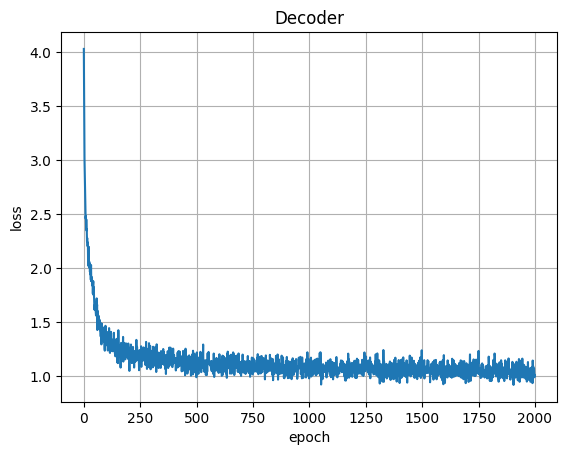

In [274]:
plt.title("Decoder")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.plot(history)
plt.grid(True)

In [275]:
def schedule_4000(step_num):
    warmup = 4000
    step_num += 1
    return MAX_LENGTH ** -0.5 * min(step_num ** -0.5, step_num * warmup ** -1.5)

def schedule_400(step_num):
    warmup = 400
    step_num += 1
    return MAX_LENGTH ** -0.5 * min(step_num ** -0.5, step_num * warmup ** -1.5)

In [ ]:
experiments = [


    {
        "model_fn": TransformerDecoderOnly,
        "model_params": {
            "max_seq_len": MAX_LENGTH,
            "vocab_size": n_tokens,
            "emb_size": 8,
            "num_layers": 1,
            "att_head_size": 16,
            "num_heads": 1,
            "att_out_size": 16,
            "ff_hidden_size": 32,
            "dropout_p": 0.1
        },
        "optimizer_fn": lambda params: torch.optim.AdamW(params, lr=1e-3),
        "scheduler_fn": None,
        "n_epochs": 2000,
        "loss": torch.nn.functional.cross_entropy,
        "train_lines": lines_train,
        "history": None,
        "writer": SummaryWriter("runs/Decoder/tiny_model")
    },

    {
        "model_fn": TransformerDecoderOnly,
        "model_params": {
            "max_seq_len": MAX_LENGTH,
            "vocab_size": n_tokens,
            "emb_size": 128,
            "num_layers": 8,
            "att_head_size": 64,
            "num_heads": 4,
            "att_out_size": 128,
            "ff_hidden_size": 256,
            "dropout_p": 0.1
        },
        "optimizer_fn": lambda params: torch.optim.AdamW(params, lr=1e-3),
        "scheduler_fn": None,
        "n_epochs": 2000,
        "loss": torch.nn.functional.cross_entropy,
        "train_lines": lines_train,
        "history": None,
        "writer": SummaryWriter("runs/Decoder/very_big_model")
    },


    {
        "model_fn": TransformerDecoderOnly,
        "model_params": {
            "max_seq_len": MAX_LENGTH,
            "vocab_size": n_tokens,
            "emb_size": 64,
            "num_layers": 4,
            "att_head_size": 32,
            "num_heads": 2,
            "att_out_size": 64,
            "ff_hidden_size": 128,
            "dropout_p": 0.0
        },
        "optimizer_fn": lambda params: torch.optim.AdamW(params, lr=1e-3),
        "scheduler_fn": None,
        "n_epochs": 2000,
        "loss": torch.nn.functional.cross_entropy,
        "train_lines": lines_train,
        "writer": SummaryWriter("runs/Decoder/dropout_0")
    },

    {
        "model_fn": TransformerDecoderOnly,
        "model_params": {
            "max_seq_len": MAX_LENGTH,
            "vocab_size": n_tokens,
            "emb_size": 64,
            "num_layers": 4,
            "att_head_size": 32,
            "num_heads": 2,
            "att_out_size": 64,
            "ff_hidden_size": 128,
            "dropout_p": 0.3
        },
        "optimizer_fn": lambda params: torch.optim.AdamW(params, lr=1e-3),
        "scheduler_fn": None,
        "n_epochs": 2000,
        "loss": torch.nn.functional.cross_entropy,
        "train_lines": lines_train,
        "writer": SummaryWriter("runs/Decoder/dropout_03")
    },


    {
        "model_fn": TransformerDecoderOnly,
        "model_params": {
            "max_seq_len": MAX_LENGTH,
            "vocab_size": n_tokens,
            "emb_size": 64,
            "num_layers": 4,
            "att_head_size": 32,
            "num_heads": 2,
            "att_out_size": 64,
            "ff_hidden_size": 128,
            "dropout_p": 0.1
        },
        "optimizer_fn": lambda params: torch.optim.AdamW(params, lr=1e-4),
        "scheduler_fn": None,
        "n_epochs": 2000,
        "loss": torch.nn.functional.cross_entropy,
        "train_lines": lines_train,
        "writer": SummaryWriter("runs/Decoder/lr_1e4")
    },

    {
        "model_fn": TransformerDecoderOnly,
        "model_params": {
            "max_seq_len": MAX_LENGTH,
            "vocab_size": n_tokens,
            "emb_size": 64,
            "num_layers": 4,
            "att_head_size": 32,
            "num_heads": 2,
            "att_out_size": 64,
            "ff_hidden_size": 128,
            "dropout_p": 0.1
        },
        "optimizer_fn": lambda params: torch.optim.AdamW(params, lr=1e-2),
        "scheduler_fn": None,
        "n_epochs": 2000,
        "loss": torch.nn.functional.cross_entropy,
        "train_lines": lines_train,
        "writer": SummaryWriter("runs/Decoder/lr_1e2")
    },


    {
        "model_fn": TransformerDecoderOnly,
        "model_params": {
            "max_seq_len": MAX_LENGTH,
            "vocab_size": n_tokens,
            "emb_size": 64,
            "num_layers": 4,
            "att_head_size": 32,
            "num_heads": 2,
            "att_out_size": 64,
            "ff_hidden_size": 128,
            "dropout_p": 0.1
        },
        "optimizer_fn": lambda params: torch.optim.AdamW(params, lr=1e-3),
        "scheduler_fn": lambda opt: torch.optim.lr_scheduler.LambdaLR(opt, schedule_4000),
        "n_epochs": 2000,
        "loss": torch.nn.functional.cross_entropy,
        "train_lines": lines_train,
        "writer": SummaryWriter("runs/Decoder/step_scheduler_4000")
    },

    {
        "model_fn": TransformerDecoderOnly,
        "model_params": {
            "max_seq_len": MAX_LENGTH,
            "vocab_size": n_tokens,
            "emb_size": 64,
            "num_layers": 4,
            "att_head_size": 32,
            "num_heads": 2,
            "att_out_size": 64,
            "ff_hidden_size": 128,
            "dropout_p": 0.1
        },
        "optimizer_fn": lambda params: torch.optim.AdamW(params, lr=1e-3),
        "scheduler_fn": lambda opt: torch.optim.lr_scheduler.LambdaLR(opt, schedule_400),
        "n_epochs": 2000,
        "loss": torch.nn.functional.cross_entropy,
        "train_lines": lines_train,
        "writer": SummaryWriter("runs/Decoder/step_scheduler_400")
    },


    {
        "model_fn": TransformerDecoderOnly,
        "model_params": {
            "max_seq_len": MAX_LENGTH,
            "vocab_size": n_tokens,
            "emb_size": 64,
            "num_layers": 4,
            "att_head_size": 32,
            "num_heads": 1,
            "att_out_size": 64,
            "ff_hidden_size": 128,
            "dropout_p": 0.1
        },
        "optimizer_fn": lambda params: torch.optim.AdamW(params, lr=1e-3),
        "scheduler_fn": None,
        "n_epochs": 2000,
        "loss": torch.nn.functional.cross_entropy,
        "train_lines": lines_train,
        "writer": SummaryWriter("runs/Decoder/heads1")
    },

    {
        "model_fn": TransformerDecoderOnly,
        "model_params": {
            "max_seq_len": MAX_LENGTH,
            "vocab_size": n_tokens,
            "emb_size": 64,
            "num_layers": 4,
            "att_head_size": 32,
            "num_heads": 8,
            "att_out_size": 64,
            "ff_hidden_size": 128,
            "dropout_p": 0.1
        },
        "optimizer_fn": lambda params: torch.optim.AdamW(params, lr=1e-3),
        "scheduler_fn": None,
        "n_epochs": 2000,
        "loss": torch.nn.functional.cross_entropy,
        "train_lines": lines_train,
        "writer": SummaryWriter("runs/Decoder/heads8")
    },


    {
        "model_fn": TransformerDecoderOnly,
        "model_params": {
            "max_seq_len": MAX_LENGTH,
            "vocab_size": n_tokens,
            "emb_size": 64,
            "num_layers": 4,
            "att_head_size": 32,
            "num_heads": 2,
            "att_out_size": 64,
            "ff_hidden_size": 64,
            "dropout_p": 0.1
        },
        "optimizer_fn": lambda params: torch.optim.AdamW(params, lr=1e-3),
        "scheduler_fn": None,
        "n_epochs": 2000,
        "loss": torch.nn.functional.cross_entropy,
        "train_lines": lines_train,
        "writer": SummaryWriter("runs/Decoder/ff64")
    },

    {
        "model_fn": TransformerDecoderOnly,
        "model_params": {
            "max_seq_len": MAX_LENGTH,
            "vocab_size": n_tokens,
            "emb_size": 64,
            "num_layers": 4,
            "att_head_size": 32,
            "num_heads": 2,
            "att_out_size": 64,
            "ff_hidden_size": 512,
            "dropout_p": 0.1
        },
        "optimizer_fn": lambda params: torch.optim.AdamW(params, lr=1e-3),
        "scheduler_fn": None,
        "n_epochs": 2000,
        "loss": torch.nn.functional.cross_entropy,
        "train_lines": lines_train,
        "writer": SummaryWriter("runs/Decoder/ff512")
    },

]

In [277]:
# run_experiments(experiments)

Посмотрим на результаты экспериментов

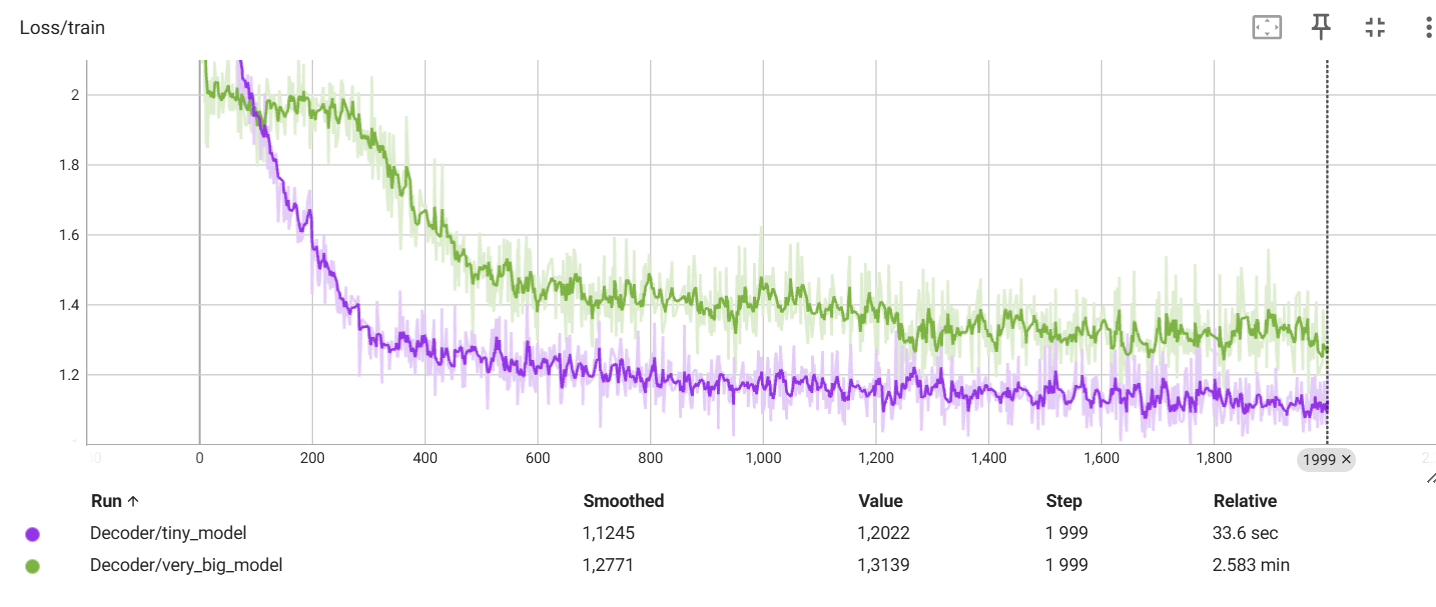

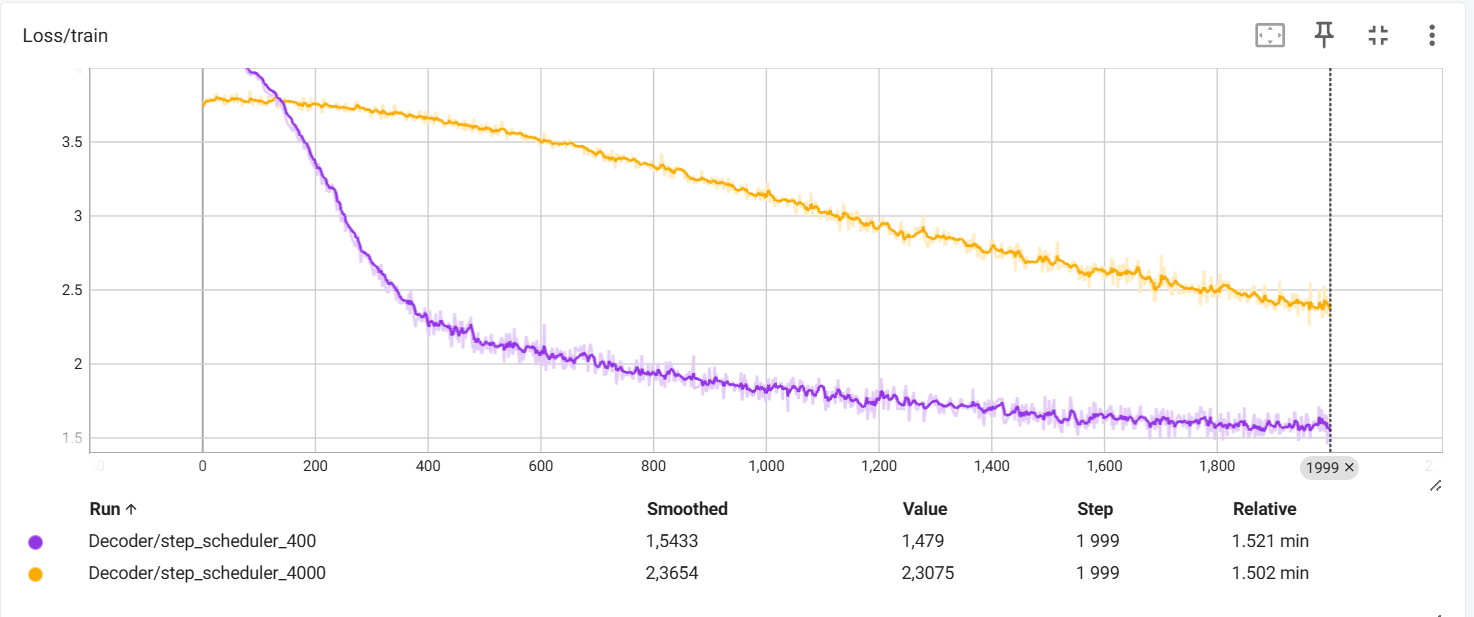

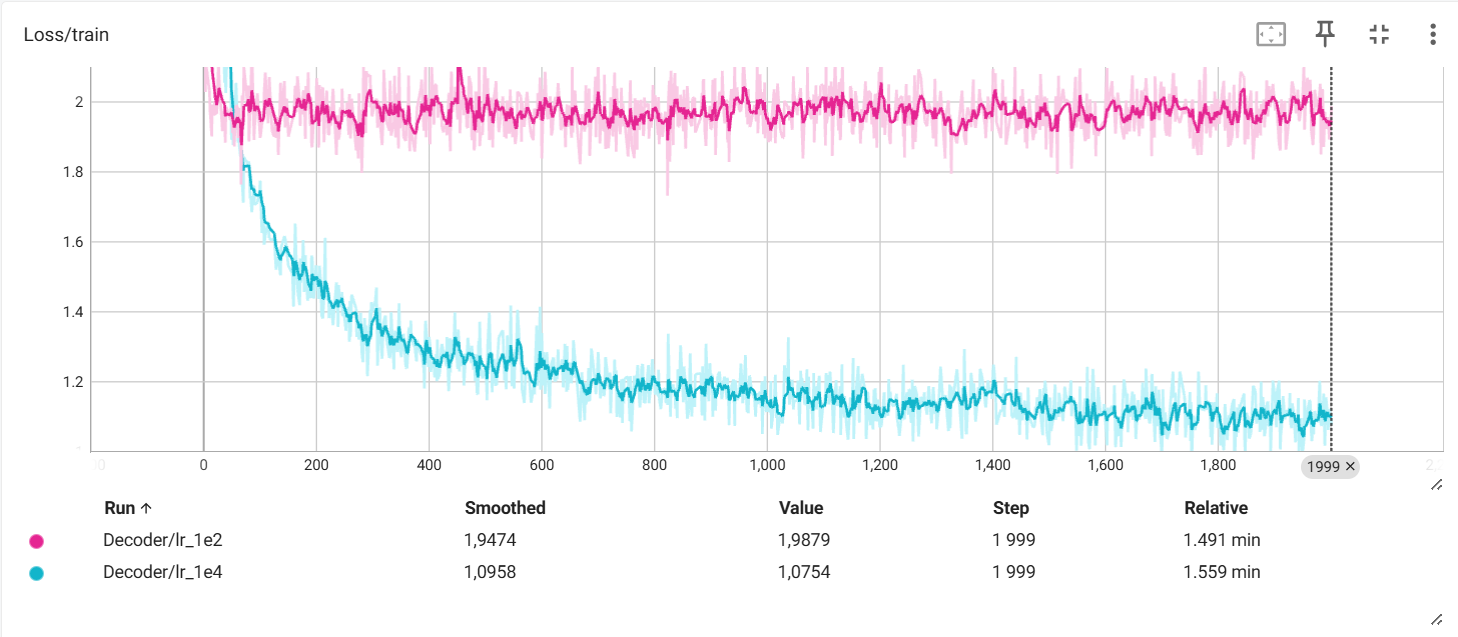

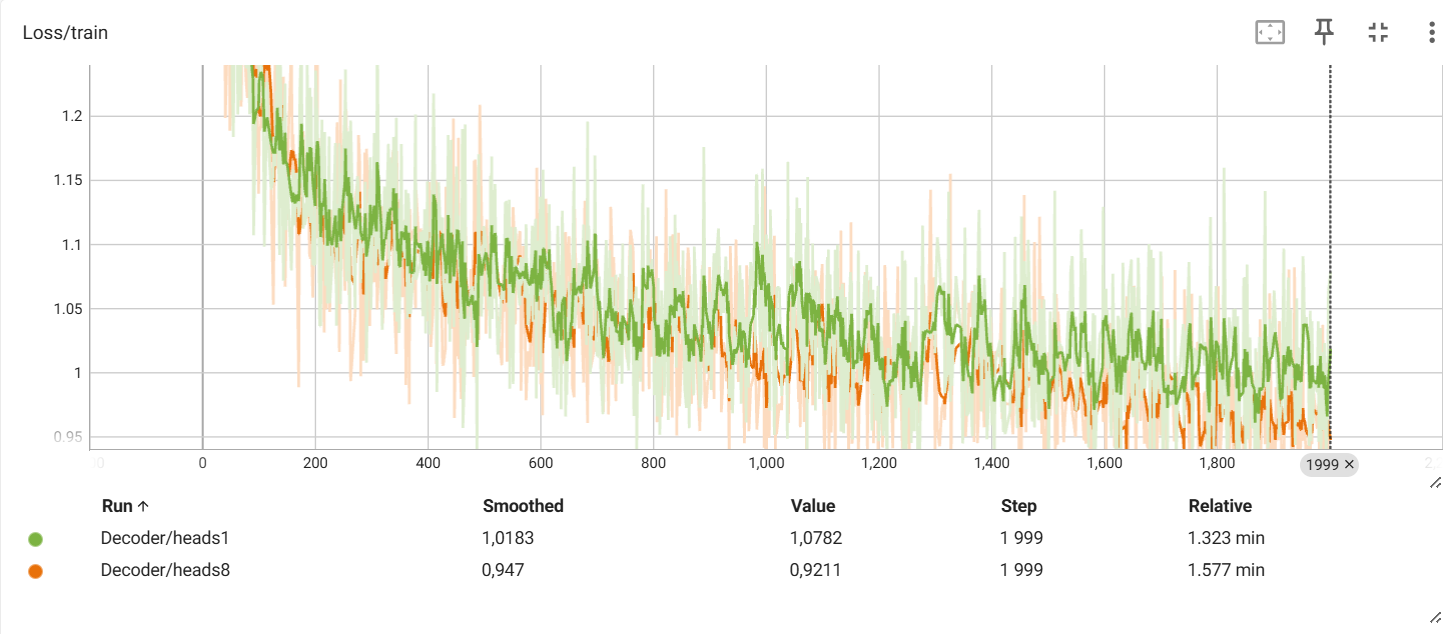

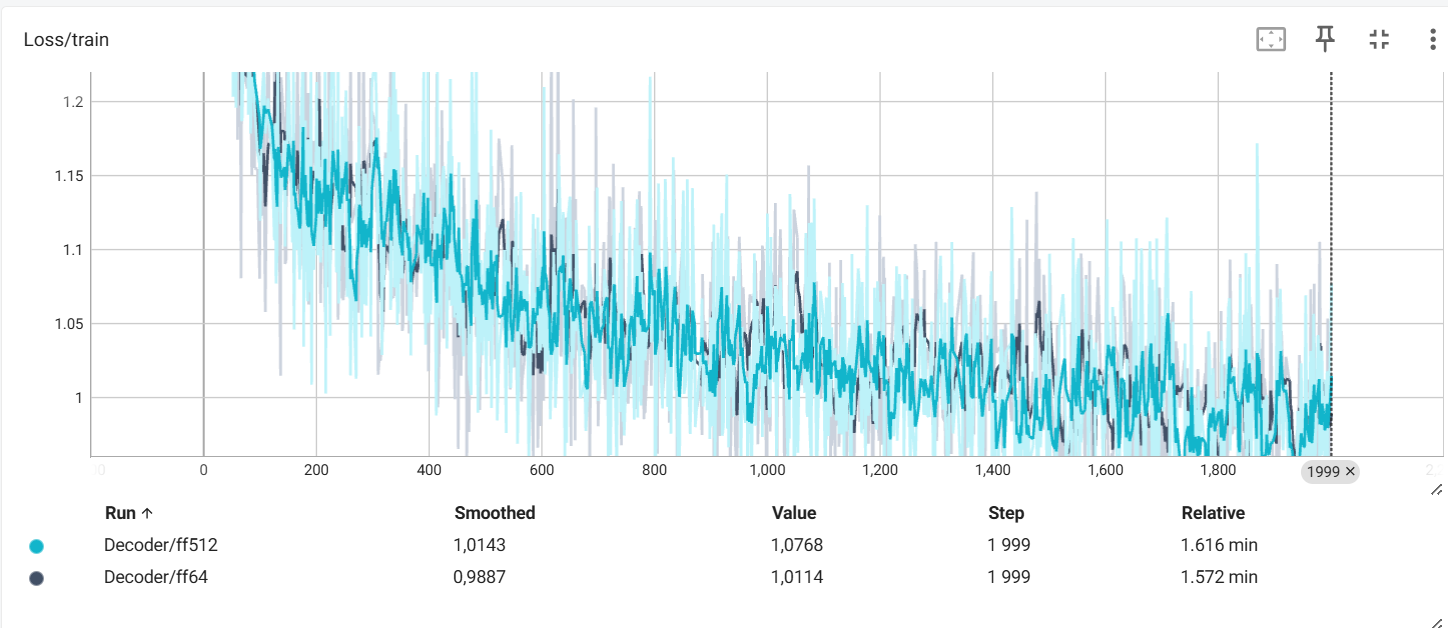

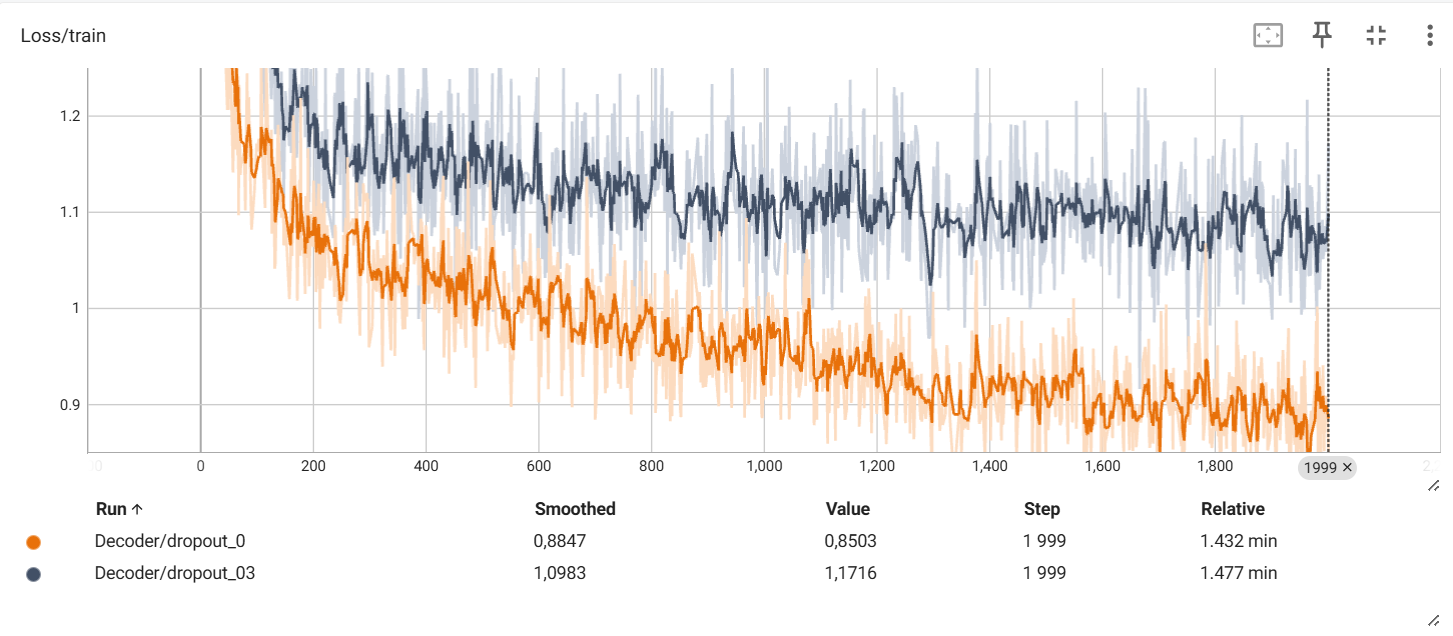

Исходя из графиков выше, я попытался подобрать оптимальные параметры для трансформера

In [337]:
decoder_model = TransformerDecoderOnly(
    max_seq_len=MAX_LENGTH,
    vocab_size=n_tokens,
    emb_size=32,
    num_layers=4,
    att_head_size=32,
    num_heads=4,
    att_out_size=32,
    ff_hidden_size=64,
    dropout_p=0.1
)
opt = torch.optim.Adam(decoder_model.parameters())
history = []

fit(decoder_model, 10_000, torch.nn.functional.cross_entropy, opt, lines_train, history)

In [338]:
perplexity(decoder_model, lines_test)

tensor(9.2801, device='cuda:0')

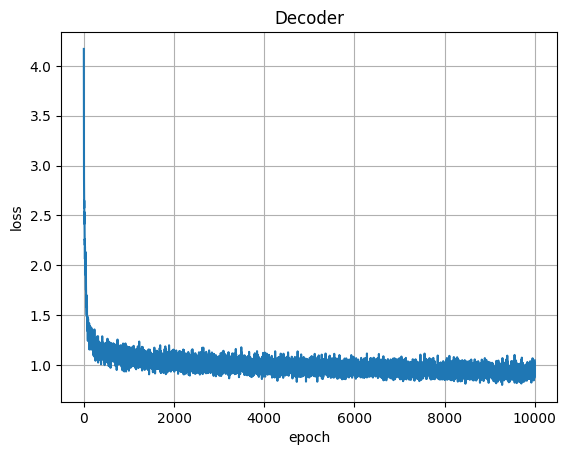

In [339]:
plt.title("Decoder")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.plot(history)
plt.grid(True)

In [281]:
decoder_model.to("cpu")
vanilla_rnn.to("cpu")
lstm_rnn.to("cpu")

LSTM(
  (embedding): Embedding(55, 128)
  (forget_gate): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): Sigmoid()
  )
  (information_gate): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): Sigmoid()
  )
  (candidate_values): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): Tanh()
  )
  (output): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): Sigmoid()
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=55, bias=True)
  )
)

In [ ]:
def generate_sample(transformer: TransformerDecoderOnly, seed_phrase=" ", temperature=1.0):
    transformer.eval()
    
    with torch.no_grad():
        seq_to_generate = torch.tensor([token_to_id[c] for c in seed_phrase])
        generated_seq = transformer.genereate(seq_to_generate, temperature)
        result_tokens = [tokens[token_id.item()] for token_id in generated_seq if token_id != 0]
    transformer.train()
    
    return "".join(result_tokens)

Сгенерируем имена через VanillaRnn

In [283]:
for _ in range(10):
    print(generate_sample(vanilla_rnn, seed_phrase=" A"))

Adubene
Aonega
Anvel
Agy
Anetane
Augin
Alise
Anvolia
Alanano
Alin


Сгенерируем имена через LSTM

In [284]:
for _ in range(10):
    print(generate_sample(lstm_rnn, seed_phrase=" A"))

Annella
Amella
Alodelina
Alver
Anna
Adi
Aneda
Aebice
Annadiamo
Arther


Сгенерируем имена через Decoder

In [285]:
for _ in range(10):
    print(generate_sample(decoder_model, seed_phrase=" A", temperature=1))

Amy
Agertan
Alanus
Ale'a
Annabasell
Amaus
Alasandr
Alvine
Abaskol
Awon


In [286]:
for _ in range(10):
    print(generate_sample(decoder_model, seed_phrase=" Trump", temperature=0.5))

Trumpie
Trumphy
Trumphi
Trumpy
Trumphe
Trumpen
Trumphin
Trumps
Trumphy
Trumphe


In [287]:
for _ in range(10):
    print(generate_sample(decoder_model, seed_phrase=" Dzhabar", temperature=1.09))

Dzhabarde
Dzhabardo
Dzhabarin
Dzhabarie
Dzhabarin
Dzhabaryn
Dzhabarinna
Dzhabaran
Dzhabaryn
Dzhabar


Как можно увидеть выше, perplexity декодера чуть хуже, чем у обычной RNN и у LSTM. При этом, если посмотреть на имена, которые генерирует декодер, они примерно такие же, как у RNN, местами даже лучше.  

Я думаю это связано с тем, что мы пытаемся обучить Transformer на последовательностях маленькой длины. В архитетуру RNN уже встроено понимание последовательности архитектурно, поэтому она лучше работает на маленьких последовательностях. В то время как Transformer работает со всей последовательностью сразу, и умеет обращаться к любому месту этой последовательности, то есть лучше работает с последовательностями большей длины (для этого собственно он и был создан).  

Из-за одновременной обработки последовательности, декодеру нужно намного больше времени (эпох), чтобы выучить паттерны последовательности.

### Генерация другого формата данных - 3 балла + бонусные 0-3 балла

Если вам наскучит решать повседневные задачи или вам нужны новые идеи, вы теперь всегда можете воспользоваться RNN или трансформером, чтобы сгенерировать что-то новое.

Вот несколько задач, от которых можно отталкиваться:
* названия статей по глубинному обучению;
* названия карт Magic The Gathering;
* [имена покемонов](https://github.com/cervoise/pentest-scripts/blob/master/password-cracking/wordlists/pokemon-list-en.txt);
* clickbait заголовки;
* молекулы в формате [smiles](https://en.wikipedia.org/wiki/Simplified_molecular-input_line-entry_system);
* ваша фантазия, с ограничениями которой вы уже должны были понять, как бороться.

Вам предлагается сделать обязательно одну какую-либо ещё задачу и, на бонусные баллы, другую.

Несколько полезных советов:
* Сейчас модель обучается на коротких строчках. Если у вас роман, его придётся порезать на кускочки.
* Если длина строк сильно варьируется, можно поставить параметр MAX_LENGTH так, чтобы он покрывал 90%. Это обычно дает ускорение примерно в 2 раза.
* Для более сложных задач требуется больше нейронов/слоев. Кроме того, можно экспериментировать и со составляющими сети (см. ниже).


In [313]:
pockemons = []
with open("data/pockemons.txt", "r") as f:
    for line in f.readlines():
        if line:
            pockemons.append(start_token + line[:-1])

pockemons = np.array(pockemons)
pockemons.shape

(721,)

In [314]:
P_MAX_LENGTH = max(map(len, pockemons))
P_MAX_LENGTH

12

In [315]:
tokens = set()

token_num = 0
for line in pockemons:
    for char in line:
        tokens.add(char)


tokens = sorted(list(tokens))
n_p_tokens = len(tokens)
print ('n_p_tokens = ', n_p_tokens)

token_to_id = {token: i for i, token in enumerate(tokens)}

n_p_tokens =  33


In [316]:
p_lstm = LSTM(
    n_tokens=n_p_tokens,
    emb_size=64,
    rnn_size=128, 
    max_seq_len=P_MAX_LENGTH,
    hidden_size=256,
)

opt = torch.optim.AdamW(lstm_rnn.parameters())
history = []
fit(
    lstm_rnn, 
    2000, 
    nn.functional.cross_entropy, 
    opt, 
    pockemons, 
    history, 
    pad=token_to_id[" "])

In [317]:
perplexity(p_lstm, pockemons)

tensor(32.7508, device='cuda:0')

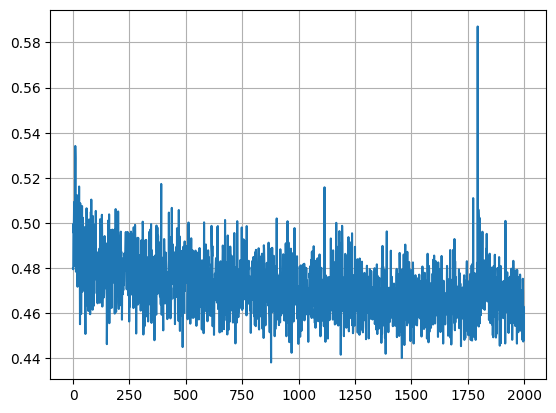

In [ ]:
plt.title("Pockemons LSTM")
plt.xlable("epoch")
plt.ylabel("loss")
plt.plot(history)
plt.grid(True)

In [319]:
p_lstm.to("cpu")

LSTM(
  (embedding): Embedding(33, 64)
  (forget_gate): Sequential(
    (0): Linear(in_features=192, out_features=128, bias=True)
    (1): Sigmoid()
  )
  (information_gate): Sequential(
    (0): Linear(in_features=192, out_features=128, bias=True)
    (1): Sigmoid()
  )
  (candidate_values): Sequential(
    (0): Linear(in_features=192, out_features=128, bias=True)
    (1): Tanh()
  )
  (output): Sequential(
    (0): Linear(in_features=192, out_features=128, bias=True)
    (1): Sigmoid()
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=33, bias=True)
  )
)

In [320]:
for _  in range(10):
    print(generate_sample(p_lstm))

ghqwdww.urc
mig♂glln
mhvnctsungj
-uyékud♂r
hixeyjjy.b2
mulzcruub.u


vémkjmt♂2hy
uh2zqri'rsu


Попробовали обучить LSTM, как то плохо получилось.  
Попробуем обучиться на трансформере

In [321]:
pockemons_decoder_model = TransformerDecoderOnly(
    max_seq_len=P_MAX_LENGTH,
    vocab_size=n_tokens,
    emb_size=32,
    num_layers=4,
    att_head_size=32,
    num_heads=4,
    att_out_size=32,
    ff_hidden_size=64,
    dropout_p=0.1
)
opt = torch.optim.Adam(pockemons_decoder_model.parameters())
history = []

fit(pockemons_decoder_model, 8_000, torch.nn.functional.cross_entropy, opt, pockemons, history)

In [323]:
perplexity(pockemons_decoder_model, pockemons)

tensor(3.5322, device='cuda:0')

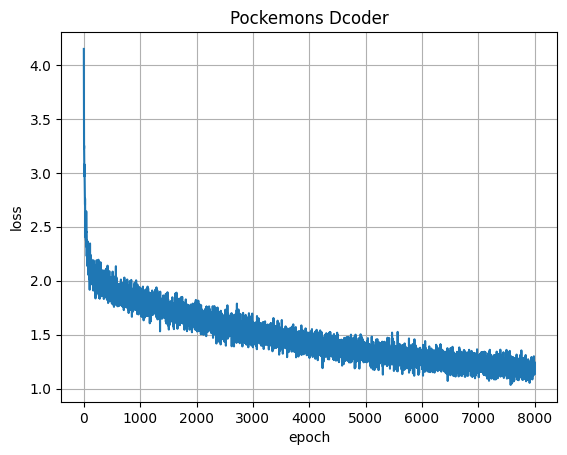

In [324]:
plt.title("Pockemons Dcoder")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.plot(history)
plt.grid(True)

In [325]:
pockemons_decoder_model.to("cpu")

TransformerDecoderOnly(
  (embedding_layer): Embedding(55, 32)
  (positional_encoder): PositionalEncoding()
  (dropout): Dropout(p=0.1, inplace=False)
  (decoder_blocks): ModuleDict(
    (decoder_block_0): TransformerDecoderOnlyBlock(
      (masked_attention): MultiHeadAttention(
        (query_matrix): Linear(in_features=32, out_features=128, bias=True)
        (key_matrix): Linear(in_features=32, out_features=128, bias=True)
        (value_matrix): Linear(in_features=32, out_features=128, bias=True)
        (out): Linear(in_features=128, out_features=32, bias=True)
      )
      (adapt_residual): Linear(in_features=32, out_features=32, bias=True)
      (norm_attention): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (ff): Sequential(
        (0): Linear(in_features=32, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=32, bias=True)
      )
      (norm_ff): LayerNorm((32,), eps=1

In [326]:
for _  in range(10):
    print(generate_sample(pockemons_decoder_model))

diara
ludia
lopuny
saqrble
pigpopop
hapiritap
lipolipee
hopdotka
espon
vunona


Несмотря на большое различие в значении финального лосса (у LSTM он меньше, чем у DecoderOnly), значение перплексии у Decoder намного меньше, чем у LSTM. И, как следствие, сгенерированные имена намного больше походи на имена покепонов.


### Ещё почитать

* [Подборка советов](https://danijar.com/tips-for-training-recurrent-neural-networks/) по обучению RNN. Чуть более полезная, чем обычно.
* Отличный блог-пост от Andrej Karpathy про языковые модели на rnn, их применение и визуализацию — [Unreasonable Effectiveness of RNN](http://karpathy.github.io/2015/05/21/rnn-effectiveness/).
* Большой список статей, постов, реализаций и прочих полезностей по RNN - [awesome rnn](https://github.com/kjw0612/awesome-rnn).
* Зоопарк готовых рекуррентных ячеек (LSTM, GRU) в [Керасе](https://keras.io/layers/recurrent/) и [PyTorch](https://pytorch.org/docs/stable/nn.html#recurrent-layers).
* Сейчас мы настраиваем количество итераций заранее. Если вы хотите определять их динамически, милости просим в [tf.while_loop](https://www.tensorflow.org/api_docs/python/tf/while_loop) или [tf.scan](https://www.tensorflow.org/api_docs/python/tf/scan).
* А ещё рекуррентные сети можно аугментировать механизмом внимания или долговременной памятью. Вот тут есть [хорошая статья](https://distill.pub/2016/augmented-rnns/).